In [99]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import os
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(NOT\s+\w+:\w+:\S+|\w+:\w+:\S+|AND|OR)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts



def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
        
    
    return unit_concepts, raw_concepts
 


In [176]:
import nltk
from nltk.corpus import wordnet as wn
from nltk import pos_tag
from collections import defaultdict
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

SUPERSENSE_TO_CATEGORY = {
    # Verbs
    "verb.motion": "actions",
    "verb.contact": "actions",
    "verb.consumption": "actions",
    "verb.stative": "states",
    "verb.perception": "states",

    # Nouns
    "noun.location": "locations",
    "noun.person": "object",
    "noun.animal": "object",
    "noun.artifact": "object",
    "noun.object": "object",
    "noun.food": "object",
    "noun.substance": "object",

    # Adjectives
    "adj.all": "adjectives",
    "adj.pert": "adjectives"
}

def to_wn_pos(word):
    doc = nlp(word)
    for token in doc:
        
        if 'NN' in token.tag_ :
            return wn.NOUN
        elif 'VB' in token.tag_  :
            return wn.VERB
        elif 'JJ' in token.tag_:
            return wn.ADJ
        elif 'RB' in token.tag_:
            return wn.ADV
    return None

def get_supersense(word, pos):
    synsets = wn.synsets(word, pos=pos)
    if not synsets:
        return None
    return synsets[0].lexname()

def is_pos_ambiguous(word):
    pos_list = []
    for pos in [wn.NOUN, wn.VERB, wn.ADJ, wn.ADV]:
        if wn.synsets(word, pos=pos):
            pos_list.append(pos)
    return len(pos_list) > 1, pos_list

def categorize_words(words):
    words =list([word.split(":")[-1] for word in words])
    categories = defaultdict(list)



    for word in words:
        if word == 'AND' or word=='OR': continue
        wn_pos = to_wn_pos(word)

        if wn_pos is None:
            categories["function_words"].append(word)
            continue

        supersense = get_supersense(word, wn_pos)

        if supersense is None:
            categories["POS"].append(word)
            continue

        category = SUPERSENSE_TO_CATEGORY.get(supersense, "other")
        categories[category].append(word)

    return dict(categories)

_, rawc1 = load_csv_data(filepath='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_5/Expls/0.27243559109531656%Pruned/Cluster1IOUS1024N.csv')
_, rawc2 = load_csv_data(filepath='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls/0.27243559109531656%Pruned/Cluster2IOUS1024N.csv')
_, rawc3 = load_csv_data(filepath='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls/0.27243559109531656%Pruned/Cluster3IOUS1024N.csv')
print("Loaded CSV Data")
categsc1=categorize_words(rawc1)
categsc2=categorize_words(rawc2)
categsc3=categorize_words(rawc3)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Loaded CSV Data


In [244]:
def count(concepts, token, remove_not=False):
    inc = 0
    for i in concepts:
        if remove_not:
            
            if token in i and 'NOT' not in i:
                inc += 1
        else:
            if token in i:
                inc += 1
    return inc
cluster_results=defaultdict(lambda: defaultdict(lambda: defaultdict()))
filepath='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_5/Expls/'
for sparisty_explanation_flder in os.listdir(filepath):
    if '.7789' in sparisty_explanation_flder: continue
    for cluster in range(1,4):
        try:
            cluster_explanations_per_unit, cluster_explanatinos_all = load_csv_data(os.path.join(filepath,sparisty_explanation_flder,f'Cluster{cluster}IOUS1024N.csv'))
            cluster_explanatinos_all = set(cluster_explanatinos_all)
        except:
            print("Skipping ", os.path.join(filepath,sparisty_explanation_flder,f'Cluster{cluster}IOUS1024N.csv'))
            continue
        pre_count = count(cluster_explanatinos_all, 'pre', True)
        
        hyp_count = count(cluster_explanatinos_all, 'hyp', True)
       
        not_count = count(cluster_explanatinos_all, "NOT")
        cluster_results[sparisty_explanation_flder][cluster]={'pre:': pre_count, 'hyp': hyp_count, 'not:':not_count, 'total': len(cluster_explanatinos_all)}

In [221]:
pd.DataFrame(cluster_results).to_csv("/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_5/concept_count_without_redundnacy.csv")

defaultdict(<function <lambda> at 0x7c95df13f010>, {1: defaultdict(<class 'list'>, {'pre': [85, 89, 90, 77, 79], 'hyp': [53, 62, 62, 64, 68], 'not': [421, 358, 369, 352, 336], 'total': [564, 514, 526, 498, 488]}), 2: defaultdict(<class 'list'>, {'pre': [117, 125, 129, 119, 122], 'hyp': [87, 102, 102, 97, 91], 'not': [189, 157, 175, 169, 162], 'total': [398, 389, 411, 390, 380]}), 3: defaultdict(<class 'list'>, {'pre': [227, 200, 211, 198, 202], 'hyp': [210, 227, 221, 216, 216], 'not': [102, 99, 89, 85, 85], 'total': [544, 531, 526, 504, 508]})})


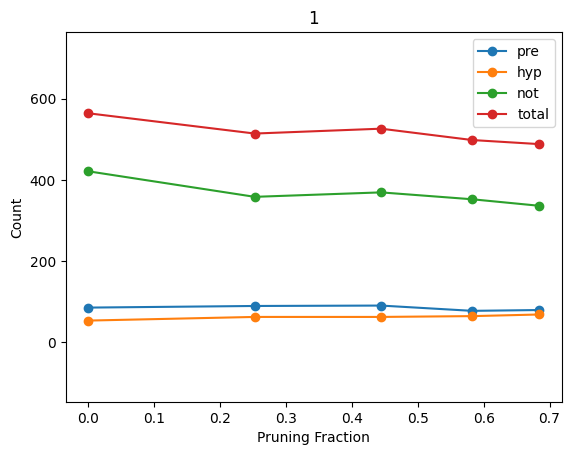

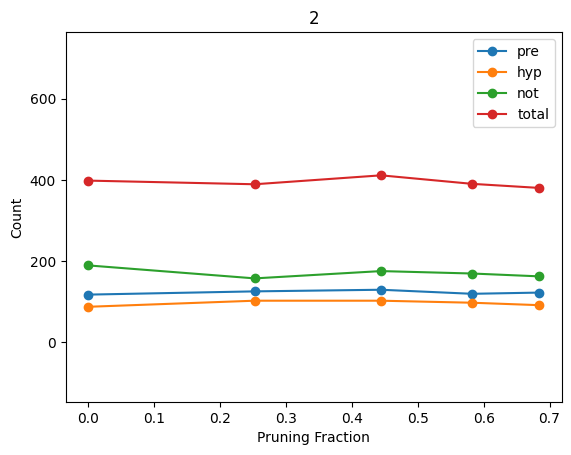

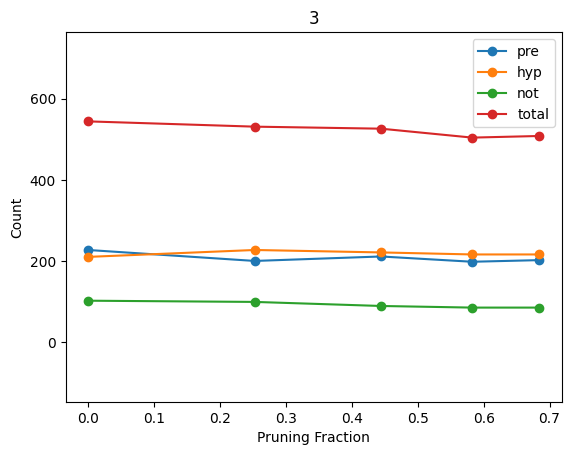

In [245]:
#uinque concept dist
import matplotlib.pyplot as plt
news=defaultdict(lambda: defaultdict(list))
for s in cluster_results:
    for c,v in cluster_results[s].items():
      
        news[c]['pre'].append(v['pre:'])
        news[c]['hyp'].append(v['hyp'])
        news[c]['not'].append(v['not:'])
        news[c]['total'].append(v['total'])
pruning = [
    0.0,
    0.25267370011269075,
    0.4443280775114645,
    0.5826748728764346,
    0.6841850626856109,
]

clusters = {
    "Cluster 1": {
        "pre": [85, 89, 90, 77, 79],
        "hyp": [53, 62, 62, 64, 68],
        "not": [421, 358, 369, 352, 336],
    },
    "Cluster 2": {
        "pre": [117, 125, 129, 119, 122],
        "hyp": [87, 102, 102, 97, 91],
        "not": [189, 157, 175, 169, 162],
    },
    "Cluster 3": {
        "pre": [227, 200, 211, 198, 202],
        "hyp": [210, 227, 221, 216, 216],
        "not": [102, 99, 89, 85, 85],
    },
}
clusters=news
print(news)

# --- compute global y-axis limits ---
all_vals = []
for c in clusters.values():
    for v in c.values():
        all_vals.extend(v)

ymin, ymax = min(all_vals)-200, max(all_vals)+200

# --- plot ---
for name, data in clusters.items():
    plt.figure()
    for key, vals in data.items():
    
        plt.plot(pruning, vals, marker='o', label=key)

    plt.ylim(ymin, ymax)        # SAME y-axis
    plt.xlabel("Pruning Fraction")
    plt.ylabel("Count")
    plt.title(name)
    plt.legend()
    plt.show()
#uniquely speaking the c1 has the most nots abd  cluste 1,2 have more pre than hyp but c3 switches to more hyp than pre but still pre and hyp are close and in some they convge (but high level is dist stays same )
#but overall c1,2 has more nots and c3 has more hyp but the pre to hyp count shifts up at each cluster (so high clusters are more r and hyp) distributiuon doesnt chane w pruning relative to total cps esp


In [190]:
import nltk
from nltk import word_tokenize, pos_tag
nltk.download('punkt_tab')
# Ensure necessary NLTK data is downloaded (run once)
nltk.download('averaged_perceptron_tagger')
import pandas as pd
from collections import defaultdict
model='BERT'
method='lottery_ticket'
file='Run0.25_5'
root = f"/workspace/CCE_NLI/{model}/exp/{method}/{file}/Expls"
counts = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
conceptslist = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
for pruned_percent in os.listdir(root):
    if '.ipy' in pruned_percent: continue
    
    for cluster in range(1,4):
        
        _, concepts = load_csv_data(filepath=os.path.join(root,pruned_percent, f'Cluster{cluster}IOUS1024N.csv'))
    

        words =list([word.split(":")[-1] for word in concepts if word not in ['AND', 'OR'] and 'tag:' not in word and 'oth:overlap' not in word])
                                    
        # 1. Tokenize the text into words
        tokens = word_tokenize(" ".join(words))

        # 2. Perform POS tagging
        # The result is a list of tuples: [('word', 'POS_tag'), ...]
        tagged_words = pos_tag(tokens)

        # 3. Filter for nouns and verbs
        nouns = [word for word, tag in tagged_words if tag.startswith('NN')]
        verbs = [word for word, tag in tagged_words if tag.startswith('VB')]
        adj = [word for word, tag in tagged_words if tag.startswith('JJ')]
                                 
        counts[pruned_percent][f'Cluster{cluster}']['Nouns'] = len(nouns)
        counts[pruned_percent][f'Cluster{cluster}']['Verbs'] = len(verbs)
        counts[pruned_percent][f'Cluster{cluster}']['Adj'] = len(adj)
        
        conceptslist[pruned_percent][f'Cluster{cluster}']['Nouns'] = nouns
        conceptslist[pruned_percent][f'Cluster{cluster}']['Verbs'] = verbs
        conceptslist[pruned_percent][f'Cluster{cluster}']['Adj'] = adj
pd.DataFrame(counts)
                                    
                                 



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,0.0%Pruned,25.0%Pruned,43.75%Pruned,57.812%Pruned,68.359%Pruned,76.27%Pruned
Cluster1,"{'Nouns': 1310, 'Verbs': 799, 'Adj': 488}","{'Nouns': 1291, 'Verbs': 793, 'Adj': 481}","{'Nouns': 1298, 'Verbs': 783, 'Adj': 488}","{'Nouns': 1304, 'Verbs': 867, 'Adj': 433}","{'Nouns': 1259, 'Verbs': 832, 'Adj': 452}","{'Nouns': 1299, 'Verbs': 846, 'Adj': 437}"
Cluster2,"{'Nouns': 1117, 'Verbs': 777, 'Adj': 455}","{'Nouns': 1249, 'Verbs': 760, 'Adj': 431}","{'Nouns': 1147, 'Verbs': 732, 'Adj': 467}","{'Nouns': 1169, 'Verbs': 700, 'Adj': 454}","{'Nouns': 1104, 'Verbs': 771, 'Adj': 441}","{'Nouns': 1124, 'Verbs': 754, 'Adj': 446}"
Cluster3,"{'Nouns': 1475, 'Verbs': 909, 'Adj': 468}","{'Nouns': 1580, 'Verbs': 920, 'Adj': 458}","{'Nouns': 1399, 'Verbs': 915, 'Adj': 526}","{'Nouns': 1504, 'Verbs': 947, 'Adj': 445}","{'Nouns': 1499, 'Verbs': 997, 'Adj': 488}","{'Nouns': 1518, 'Verbs': 964, 'Adj': 492}"


In [ ]:
conceptslist["0.0%Pruned"]['Cluster3']['Adj']

**OLD**

In [58]:
import spacy
nlp = spacy.load("en_core_web_sm")  # large model, trained on huge corpus

doc = nlp("sand")
for token in doc:
    print(token.text, token.pos_, token.tag_)


sand VERB VB


In [61]:
import nltk
from nltk.corpus import wordnet as wn
from collections import defaultdict

# Ensure resources are downloaded
nltk.download("wordnet")
nltk.download("omw-1.4")

# Mapping WordNet lexnames (supersenses) to semantic categories
SUPERSENSE_TO_CATEGORY = {
    # Verbs
    "verb.motion": "actions",
    "verb.contact": "actions",
    "verb.consumption": "actions",
    "verb.stative": "states",
    "verb.perception": "states",

    # Nouns
    "noun.location": "locations",
    "noun.person": "entities",
    "noun.animal": "entities",
    "noun.artifact": "entities",
    "noun.object": "entities",
    "noun.food": "entities",
    "noun.substance": "entities",

    # Adjectives
    "adj.all": "attributes",
    "adj.pert": "attributes"
}

def get_word_pos_set(word):
    """Return all POS in WordNet for this word"""
    pos_set = set()
    for pos in [wn.NOUN, wn.VERB, wn.ADJ, wn.ADV]:
        if wn.synsets(word, pos=pos):
            pos_set.add(pos)
    return pos_set

def categorize_word(word):
    pos_set = get_word_pos_set(word)
    
    # No synsets at all → abstract
    if not pos_set:
        return "abstract"
    
    # Multiple POS → ambiguous → abstract
    if len(pos_set) > 1:
        for i in range(len(pos_set)):
            pos_set.update(get_word_pos_set(word))
        print(Counter(pos_set))
        
    
    # Single POS → pick dominant sense (first synset)
    pos = pos_set.pop()
    synset = wn.synsets(word, pos=pos)[0]
    lexname = synset.lexname()
    return SUPERSENSE_TO_CATEGORY.get(lexname, "abstract")

def categorize_words(words):
    categories = defaultdict(list)
    for word in words:
        cat = categorize_word(word.lower())
        categories[cat].append(word)
    return dict(categories)

# Example usage
words = [
    "running", "swimming", "sleeping", "asleep",
    "inside", "outside", "outdoors",
    "person", "people", "dog", "cat",
    "tall", "blue",
    "to", "for", "they", "is",
    "horse", "sand"
]

result = categorize_words(words)
print(result)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


NameError: name 'Counter' is not defined